In [1]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
adata_vis = sc.read_h5ad('../data/simulation_Mouse_Kidney_MERFISH/MK_simulated_ST.h5ad')
pred_df = pd.read_csv('./destvi_predicted_proportions.csv')

In [3]:
# 都转成字符串类型
pred_df.index = pred_df.index.astype(str)

发现 'true_proportion'，开始计算与预测值的相关性。

预测丰度与真实丰度的皮尔逊相关系数 (按细胞类型):
immune cell                                        0.804042
kidney loop of Henle epithelial cell               0.944542
endothelial cell                                   0.587462
kidney collecting duct epithelial cell             0.839799
epithelial cell of proximal tubule                 0.968672
podocyte                                           0.822586
pericyte                                           0.811724
kidney distal convoluted tubule epithelial cell    0.784535
dtype: float64
相关性柱状图已保存为 'destvi_validation_correlation.png'


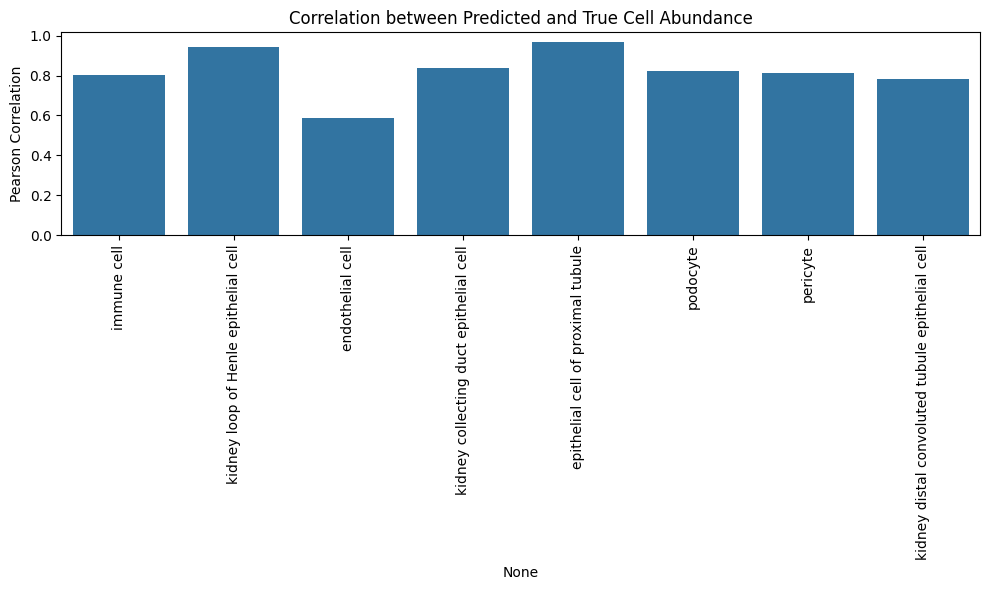

In [4]:
# 可选验证：与 true_proportion 的相关性
if 'true_proportion' in adata_vis.obsm:
    print("发现 'true_proportion'，开始计算与预测值的相关性。")
    true_df = pd.DataFrame(adata_vis.obsm['true_proportion'],
                           index=adata_vis.obs_names,
                           columns=adata_vis.uns['cell_types'])
    common_cell_types = list(set(pred_df.columns) & set(true_df.columns))
    if not common_cell_types:
        print("警告：预测的细胞类型和真实的细胞类型没有交集，无法进行相关性比较！")
    else:
        pred_c = pred_df[common_cell_types]
        true_c = true_df[common_cell_types]
        correlations = pred_c.corrwith(true_c, axis=0)
        print("\n预测丰度与真实丰度的皮尔逊相关系数 (按细胞类型):")
        print(correlations)
        plt.figure(figsize=(10, 6))
        sns.barplot(x=correlations.index, y=correlations.values)
        plt.xticks(rotation=90)
        plt.ylabel("Pearson Correlation")
        plt.title("Correlation between Predicted and True Cell Abundance")
        plt.tight_layout()
        plt.savefig("destvi_validation_correlation.png", dpi=300)
        print("相关性柱状图已保存为 'destvi_validation_correlation.png'")
else:
    print("在空间数据中未找到 'true_proportion'，跳过验证步骤。")
